In [218]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [219]:
#loading the dataset
df=pd.read_pickle(r'D:\DataScience\GUVI\Local\Telangana_govt_Ration_distribution_clustering\master_dataset.pkl')

In [220]:
#column data types
df.dtypes

distCode               int64
distName_x               str
officeCode_x           int64
officeName_x             str
shopNo                 int64
month                  int64
year                   int64
noOfRcs                int64
noOfTrans              int64
riceAfsc             float64
riceFsc              float64
riceAap              float64
wheat                float64
sugar                float64
rgdal                float64
kerosene             float64
totalAmount          float64
salt                 float64
otherShopTransCnt      int64
rcNfsaAay            float64
unitsNfsaAay         float64
rcNfsaPhh            float64
unitsNfsaPhh         float64
totalRcNfsa          float64
totalUnitsNfsa       float64
rcStateAay           float64
unitsStateAay        float64
rcStatePhh           float64
unitsStatePhh        float64
rcStateAap           float64
unitsStateAap        float64
totalRcState         float64
totalUnitsState      float64
totalRcs             float64
totalUnits    

In [221]:
df.isna().sum()

distCode                  0
distName_x                0
officeCode_x              0
officeName_x              0
shopNo                    0
month                     0
year                      0
noOfRcs                   0
noOfTrans                 0
riceAfsc                  0
riceFsc                   0
riceAap                   0
wheat                     0
sugar                     0
rgdal                     0
kerosene                  0
totalAmount               0
salt                      0
otherShopTransCnt         0
rcNfsaAay               154
unitsNfsaAay            154
rcNfsaPhh               154
unitsNfsaPhh            154
totalRcNfsa             154
totalUnitsNfsa          154
rcStateAay              154
unitsStateAay           154
rcStatePhh              154
unitsStatePhh           154
rcStateAap              154
unitsStateAap           154
totalRcState            154
totalUnitsState         154
totalRcs                154
totalUnits              154
cardTypeId          

In [222]:
null_percentage = (df.isnull().sum() / len(df)) * 100

print(null_percentage.sort_values(ascending=False))

mroAsoApprDate       100.000000
cardPoolType         100.000000
cardTypeId           100.000000
address                0.954272
distName               0.884623
longitude              0.884623
officeName             0.884623
officeCode             0.884623
dateTime               0.884623
latitude               0.884623
fpsStatus              0.884623
fpsType                0.884623
unitsNfsaAay           0.030822
rcNfsaPhh              0.030822
unitsNfsaPhh           0.030822
rcNfsaAay              0.030822
rcStateAay             0.030822
gasCylinders           0.030822
unitsStateAay          0.030822
totalUnitsState        0.030822
totalRcState           0.030822
unitsStatePhh          0.030822
rcStatePhh             0.030822
unitsStateAap          0.030822
rcStateAap             0.030822
totalUnits             0.030822
totalRcs               0.030822
totalUnitsNfsa         0.030822
totalRcNfsa            0.030822
units                  0.030822
totalAmount            0.000000
officeCo

In [223]:
df.drop([ 'mroAsoApprDate',
 'cardPoolType',
 'cardTypeId', 'address'], axis=1, inplace=True)

In [224]:
df['officeCode'].head(10)

0    532001.0
1    532001.0
2    532001.0
3    532001.0
4    532001.0
5    532001.0
6    532001.0
7    532001.0
8    532001.0
9    532001.0
Name: officeCode, dtype: float64

In [225]:
df['officeCode'] = (df['officeCode']
                    .fillna(-1)
                    .astype(int)
                    .astype(str)
                    .replace('-1', 'Unknown'))

In [226]:
df['fpsStatus'].value_counts(dropna=False)

fpsStatus
Active    495228
NaN         4420
Name: count, dtype: int64

In [227]:
df['fpsType'].value_counts(dropna=False)

fpsType
Normal Shop    495228
NaN              4420
Name: count, dtype: int64

In [228]:
cols = ['distName', 'officeName', 'fpsStatus', 'fpsType']

df[cols] = df[cols].fillna('Unknown')

In [229]:
df.drop(['dateTime'], axis=1, inplace=True)

In [230]:
df.isna().sum()

distCode                0
distName_x              0
officeCode_x            0
officeName_x            0
shopNo                  0
month                   0
year                    0
noOfRcs                 0
noOfTrans               0
riceAfsc                0
riceFsc                 0
riceAap                 0
wheat                   0
sugar                   0
rgdal                   0
kerosene                0
totalAmount             0
salt                    0
otherShopTransCnt       0
rcNfsaAay             154
unitsNfsaAay          154
rcNfsaPhh             154
unitsNfsaPhh          154
totalRcNfsa           154
totalUnitsNfsa        154
rcStateAay            154
unitsStateAay         154
rcStatePhh            154
unitsStatePhh         154
rcStateAap            154
unitsStateAap         154
totalRcState          154
totalUnitsState       154
totalRcs              154
totalUnits            154
units                 154
gasCylinders          154
distName                0
officeCode  

In [231]:
df[['rcNfsaAay', 'unitsNfsaAay', 'rcNfsaPhh', 'unitsNfsaPhh', 'totalRcNfsa', 'totalUnitsNfsa', 'rcStateAay', 'unitsStateAay', 'rcStatePhh', 'unitsStatePhh', 'rcStateAap', 'unitsStateAap', 'totalRcState', 'totalUnitsState', 'totalRcs', 'totalUnits', 'units', 'gasCylinders']].head(10)

,rcNfsaAay,unitsNfsaAay,rcNfsaPhh,unitsNfsaPhh,totalRcNfsa,totalUnitsNfsa,rcStateAay,unitsStateAay,rcStatePhh,unitsStatePhh,rcStateAap,unitsStateAap,totalRcState,totalUnitsState,totalRcs,totalUnits,units,gasCylinders
0,39.0,131.0,919.0,2953.0,958.0,3084.0,0.0,0.0,150.0,308.0,0.0,0.0,150.0,308.0,1108.0,3392.0,0.0,0.0
1,20.0,70.0,258.0,1070.0,278.0,1140.0,0.0,0.0,306.0,737.0,0.0,0.0,306.0,737.0,584.0,1877.0,0.0,0.0
2,17.0,60.0,158.0,596.0,175.0,656.0,0.0,0.0,117.0,296.0,0.0,0.0,117.0,296.0,292.0,952.0,0.0,0.0
3,14.0,45.0,190.0,777.0,204.0,822.0,0.0,0.0,200.0,525.0,1.0,1.0,201.0,526.0,405.0,1348.0,0.0,0.0
4,156.0,528.0,528.0,2053.0,684.0,2581.0,0.0,0.0,286.0,747.0,0.0,0.0,286.0,747.0,970.0,3328.0,0.0,0.0
5,40.0,122.0,371.0,1227.0,411.0,1349.0,0.0,0.0,119.0,271.0,0.0,0.0,119.0,271.0,530.0,1620.0,0.0,0.0
6,11.0,43.0,225.0,874.0,236.0,917.0,0.0,0.0,315.0,754.0,0.0,0.0,315.0,754.0,551.0,1671.0,0.0,0.0
7,66.0,209.0,142.0,580.0,208.0,789.0,0.0,0.0,160.0,379.0,0.0,0.0,160.0,379.0,368.0,1168.0,0.0,0.0
8,22.0,81.0,244.0,970.0,266.0,1051.0,0.0,0.0,71.0,190.0,0.0,0.0,71.0,190.0,337.0,1241.0,0.0,0.0
9,117.0,399.0,406.0,1749.0,523.0,2148.0,0.0,0.0,396.0,979.0,0.0,0.0,396.0,979.0,919.0,3127.0,0.0,0.0


In [232]:
cols_154 = [
    "rcNfsaAay", "unitsNfsaAay",
    "rcNfsaPhh", "unitsNfsaPhh",
    "totalRcNfsa", "totalUnitsNfsa",
    "rcStateAay", "unitsStateAay",
    "rcStatePhh", "unitsStatePhh",
    "rcStateAap", "unitsStateAap",
    "totalRcState", "totalUnitsState",
    "totalRcs", "totalUnits",
    "units", "gasCylinders"
]

rows_154 = df[df[cols_154].isna().all(axis=1)]

print("Number of rows:", len(rows_154))

# Save to CSV
rows_154.to_csv("154_missing_rows.csv", index=False)

print("Saved successfully as 154_missing_rows.csv")

Number of rows: 154
Saved successfully as 154_missing_rows.csv


In [233]:
df = df.drop(rows_154.index)

In [234]:
df.isna().sum()

distCode                0
distName_x              0
officeCode_x            0
officeName_x            0
shopNo                  0
month                   0
year                    0
noOfRcs                 0
noOfTrans               0
riceAfsc                0
riceFsc                 0
riceAap                 0
wheat                   0
sugar                   0
rgdal                   0
kerosene                0
totalAmount             0
salt                    0
otherShopTransCnt       0
rcNfsaAay               0
unitsNfsaAay            0
rcNfsaPhh               0
unitsNfsaPhh            0
totalRcNfsa             0
totalUnitsNfsa          0
rcStateAay              0
unitsStateAay           0
rcStatePhh              0
unitsStatePhh           0
rcStateAap              0
unitsStateAap           0
totalRcState            0
totalUnitsState         0
totalRcs                0
totalUnits              0
units                   0
gasCylinders            0
distName                0
officeCode  

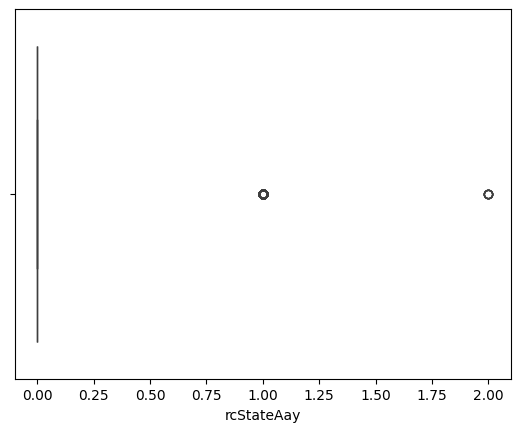

In [235]:
sns.boxplot(data=df, x='rcStateAay')
plt.show()

In [236]:
print("Zero values:", (df['rcStateAay'] == 0).sum())
print("Non-zero values:", (df['rcStateAay'] != 0).sum())

Zero values: 499362
Non-zero values: 132


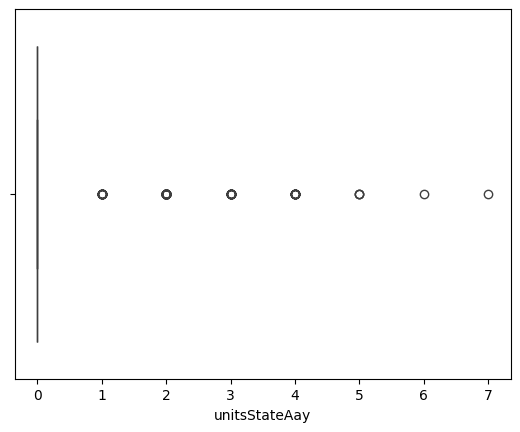

In [237]:
sns.boxplot(data=df, x='unitsStateAay')
plt.show()

In [238]:
print("Zero values:", (df['unitsStateAay'] == 0).sum())
print("Non-zero values:", (df['unitsStateAay'] != 0).sum())

Zero values: 499362
Non-zero values: 132


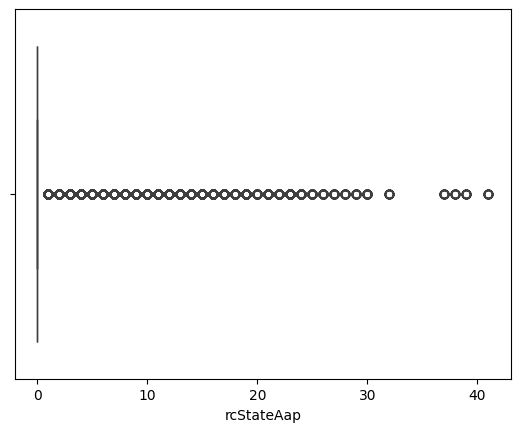

In [239]:
sns.boxplot(data=df, x='rcStateAap')
plt.show()

In [240]:
print("Zero values:", (df['rcStateAap'] == 0).sum())
print("Non-zero values:", (df['rcStateAap'] != 0).sum())

Zero values: 454690
Non-zero values: 44804


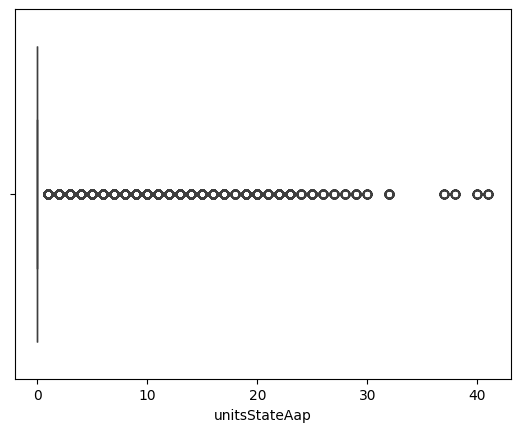

In [241]:
sns.boxplot(data=df, x='unitsStateAap')
plt.show()

In [242]:
print("Zero values:", (df['unitsStateAap'] == 0).sum())
print("Non-zero values:", (df['unitsStateAap'] != 0).sum())

Zero values: 454690
Non-zero values: 44804


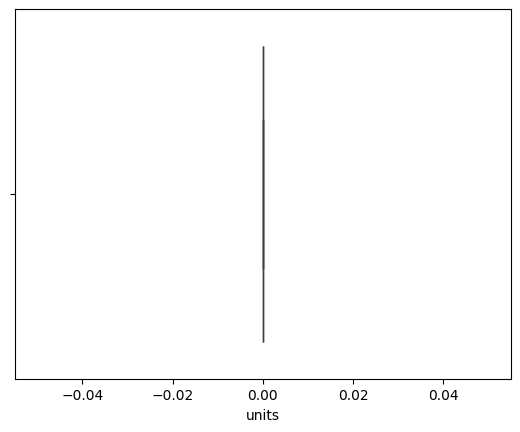

In [243]:
sns.boxplot(data=df, x='units')
plt.show()

In [244]:
print("Zero values:", (df['units'] == 0).sum())
print("Non-zero values:", (df['units'] != 0).sum())

Zero values: 499494
Non-zero values: 0


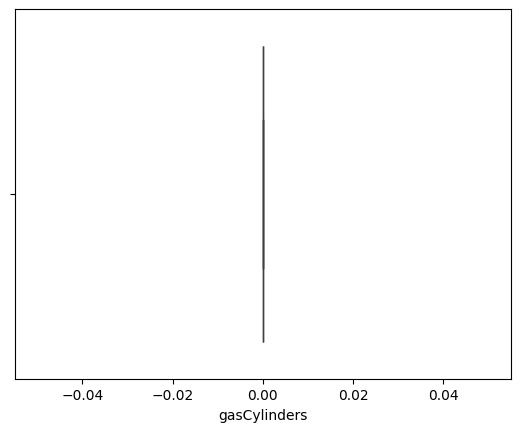

In [245]:
sns.boxplot(data=df, x='gasCylinders')
plt.show()

In [246]:
print("Zero values:", (df['gasCylinders'] == 0).sum())
print("Non-zero values:", (df['gasCylinders'] != 0).sum())

Zero values: 499494
Non-zero values: 0


In [247]:
cols = [
    "rcStateAay",
    "unitsStateAay",
    "rcStateAap",
    "unitsStateAap",
    "units",
    "gasCylinders"
]

zero_percentage = (df[cols] == 0).mean() * 100

print(zero_percentage.sort_values(ascending=False))

units            100.000000
gasCylinders     100.000000
unitsStateAay     99.973573
rcStateAay        99.973573
unitsStateAap     91.030122
rcStateAap        91.030122
dtype: float64


In [248]:
df.drop(columns=["units", "gasCylinders"], inplace=True)

In [249]:
for col in ["rcStateAay", "unitsStateAay"]:
    print(col)
    print(df[col][df[col] != 0].describe())

rcStateAay
count    132.000000
mean       1.045455
std        0.209092
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        2.000000
Name: rcStateAay, dtype: float64
unitsStateAay
count    132.000000
mean       2.431818
std        1.133751
min        1.000000
25%        2.000000
50%        2.000000
75%        3.000000
max        7.000000
Name: unitsStateAay, dtype: float64


In [250]:
for col in ["rcStateAap", "unitsStateAap"]:
    print(col)
    print("Non-zero:", (df[col] != 0).sum())
    print(df.loc[df[col] != 0, col].describe())

rcStateAap
Non-zero: 44804
count    44804.000000
mean         3.337581
std          4.868796
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         41.000000
Name: rcStateAap, dtype: float64
unitsStateAap
Non-zero: 44804
count    44804.000000
mean         3.476676
std          4.951508
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         41.000000
Name: unitsStateAap, dtype: float64


In [251]:
df["date"] = pd.to_datetime(
    dict(
        year=df["year"],
        month=df["month"],
        day=1
    )
)

In [252]:
df = df.sort_values(["shopNo", "date"])

In [253]:
pd.to_pickle(df, r'D:\DataScience\GUVI\Local\Telangana_govt_Ration_distribution_clustering\master_dataset_cleaned.pkl')

In [256]:
df.columns.to_list()

['distCode',
 'distName_x',
 'officeCode_x',
 'officeName_x',
 'shopNo',
 'month',
 'year',
 'noOfRcs',
 'noOfTrans',
 'riceAfsc',
 'riceFsc',
 'riceAap',
 'wheat',
 'sugar',
 'rgdal',
 'kerosene',
 'totalAmount',
 'salt',
 'otherShopTransCnt',
 'rcNfsaAay',
 'unitsNfsaAay',
 'rcNfsaPhh',
 'unitsNfsaPhh',
 'totalRcNfsa',
 'totalUnitsNfsa',
 'rcStateAay',
 'unitsStateAay',
 'rcStatePhh',
 'unitsStatePhh',
 'rcStateAap',
 'unitsStateAap',
 'totalRcState',
 'totalUnitsState',
 'totalRcs',
 'totalUnits',
 'distName',
 'officeCode',
 'officeName',
 'longitude',
 'latitude',
 'fpsStatus',
 'fpsType',
 'date']